In [1]:
!pip install kaggle
!pip install tensorflow keras
!pip install efficientnet

In [2]:
import os
import json

dataset_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter3 Data\\Soil_Data_V3'
data = []

for class_name in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            data.append({"class": class_name, "file_path": img_path})

with open('dataset_metadata.json', 'w') as json_file:
    json.dump(data, json_file)


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [4]:
train_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter3 Data\\Soil_Data_V3\\Trains'
test_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter3 Data\\Soil_Data_V3\\Tests'

In [5]:
# Define ImageDataGenerators for loading the data
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)


In [6]:
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')


Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


In [7]:
def build_hybrid_model():
    # Load ResNet50 and MobileNetV2 as base models
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    # Freeze base models to prevent training
    resnet.trainable = False
    mobilenet.trainable = False

    # Combine outputs of both models
    resnet_output = resnet.output
    mobilenet_output = mobilenet.output

    # Global Average Pooling
    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    # Concatenate both outputs
    combined = layers.concatenate([resnet_output, mobilenet_output])

    # Add dense layers for classification
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create model
    model = models.Model(inputs=[resnet.input, mobilenet.input], outputs=output)

    return model

In [8]:
# Step 6: Compile the model
hybrid_model = build_hybrid_model()
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
# ResNet50 baseline
resnet_model = ResNet50(include_top=True, input_shape=(224, 224, 3), weights=None, classes=train_generator.num_classes)
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = resnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=40
)

C:\Users\HP\anaconda31\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3411 - loss: 2.8564

C:\Users\HP\anaconda31\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


114/114 ━━━━━━━━━━━━━━━━━━━━ 817s 7s/step - accuracy: 0.3416 - loss: 2.8487 - val_accuracy: 0.1837 - val_loss: 2.1619
Epoch 2/40
  1/114 ━━━━━━━━━━━━━━━━━━━━ 11:23 6s/step - accuracy: 0.4062 - loss: 1.3708

C:\Users\HP\anaconda31\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4062 - loss: 1.3708 - val_accuracy: 0.2000 - val_loss: 2.3508
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 755s 7s/step - accuracy: 0.4831 - loss: 1.3583 - val_accuracy: 0.2270 - val_loss: 2.4043
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5938 - loss: 1.3702 - val_accuracy: 0.2667 - val_loss: 2.0723
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 767s 7s/step - accuracy: 0.5105 - loss: 1.3358 - val_accuracy: 0.3048 - val_loss: 4.6711
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5000 - loss: 1.2277 - val_accuracy: 0.4000 - val_loss: 4.3292
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 750s 7s/step - accuracy: 0.5158 - loss: 1.3110 - val_accuracy: 0.1926 - val_loss: 25.6936
Epoch 8/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5312 - loss: 1.7635 - val_accuracy: 0.1333 - val_loss: 184.0488
Epoch 9/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 750s 7s/step - accuracy: 0.4160 - loss: 1.5584 - val_accuracy: 0.2851

In [10]:
# MobileNetV2 baseline
mobilenet_model = MobileNetV2(include_top=True, input_shape=(224, 224, 3), weights=None, classes=train_generator.num_classes)
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = mobilenet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=40
)

Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 358s 3s/step - accuracy: 0.3517 - loss: 1.8387 - val_accuracy: 0.1983 - val_loss: 2.0674
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5312 - loss: 1.1869 - val_accuracy: 0.3333 - val_loss: 1.9877
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 338s 3s/step - accuracy: 0.4950 - loss: 1.3494 - val_accuracy: 0.1333 - val_loss: 2.0811
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5000 - loss: 1.0772 - val_accuracy: 0.0000e+00 - val_loss: 2.0928
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 337s 3s/step - accuracy: 0.5320 - loss: 1.2049 - val_accuracy: 0.1307 - val_loss: 2.1660
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3438 - loss: 1.6468 - val_accuracy: 0.2667 - val_loss: 2.0723
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 340s 3s/step - accuracy: 0.5428 - loss: 1.2020 - val_accuracy: 0.1327 - val_loss: 2.1891
Epoch 8/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6875 - loss: 0.8114 - val_accu

In [11]:
def build_hybrid_model():
    # Load ResNet50 and MobileNetV2 as base models
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    # Freeze base models to prevent training
    resnet.trainable = False
    mobilenet.trainable = False

    # Use one input tensor for both models
    input_tensor = layers.Input(shape=(224, 224, 3))

    # Pass the input to both models
    resnet_output = resnet(input_tensor)
    mobilenet_output = mobilenet(input_tensor)

    # Global Average Pooling
    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    # Concatenate both outputs
    combined = layers.concatenate([resnet_output, mobilenet_output])

    # Add dense layers for classification
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create model
    model = models.Model(inputs=input_tensor, outputs=output)

    return model


In [12]:
# Compile the hybrid model
hybrid_model = build_hybrid_model()
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the hybrid model (No need to pass two data generators)
history_hybrid = hybrid_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=40
)


Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 316s 3s/step - accuracy: 0.3924 - loss: 1.7745 - val_accuracy: 0.5778 - val_loss: 1.1007
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6562 - loss: 0.9603 - val_accuracy: 0.6667 - val_loss: 0.9379
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.6730 - loss: 0.9548 - val_accuracy: 0.7105 - val_loss: 0.8323
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7812 - loss: 0.8086 - val_accuracy: 0.8000 - val_loss: 0.7673
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.7034 - loss: 0.8402 - val_accuracy: 0.6939 - val_loss: 0.8607
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7812 - loss: 0.8010 - val_accuracy: 0.6000 - val_loss: 0.7812
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 304s 3s/step - accuracy: 0.7391 - loss: 0.7298 - val_accuracy: 0.6983 - val_loss: 0.7784
Epoch 8/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7188 - loss: 1.0040 - val_accurac

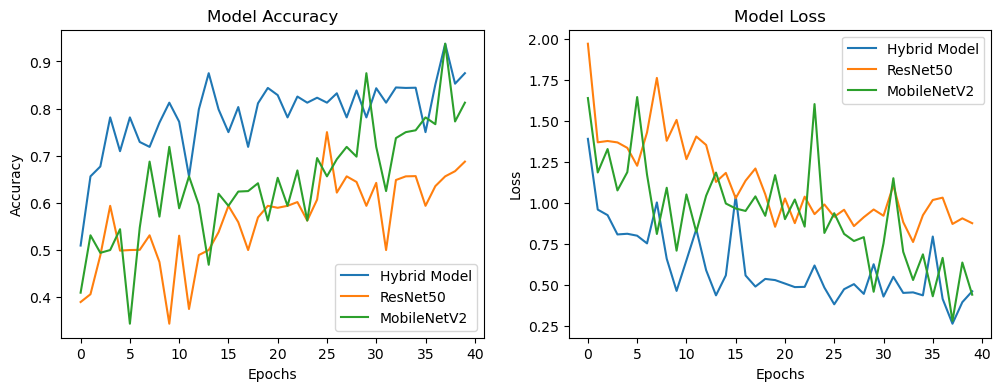

In [13]:
# Step 9: Compare the hybrid model with the baseline models

# Plot the accuracy and loss for comparison
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'], label='Hybrid Model')
plt.plot(history_resnet.history['accuracy'], label='ResNet50')
plt.plot(history_mobilenet.history['accuracy'], label='MobileNetV2')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'], label='Hybrid Model')
plt.plot(history_resnet.history['loss'], label='ResNet50')
plt.plot(history_mobilenet.history['loss'], label='MobileNetV2')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [14]:
# Step 10: Evaluate the hybrid model
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(test_generator)
print(f'Hybrid Model Accuracy: {hybrid_accuracy:.2f}')


50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8201 - loss: 0.5550
Hybrid Model Accuracy: 0.82


In [15]:
import pandas as pd

# Step 8: Evaluate the Models and Collect Data

# Evaluate MobileNetV2
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_generator)
print(f'MobileNetV2 Accuracy: {mobilenet_accuracy:.2f}')

# Evaluate ResNet50
resnet_loss, resnet_accuracy = resnet_model.evaluate(test_generator)
print(f'ResNet50 Accuracy: {resnet_accuracy:.2f}')

# Evaluate Hybrid Model
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(test_generator)
print(f'Hybrid Model Accuracy: {hybrid_accuracy:.2f}')

# Step 9: Store results in a table (Pandas DataFrame)

comparison_data = {
    'Model': ['MobileNetV2', 'ResNet50', 'Hybrid Model'],
    'Test Accuracy': [mobilenet_accuracy, resnet_accuracy, hybrid_accuracy],
    'Test Loss': [mobilenet_loss, resnet_loss, hybrid_loss]
}

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display the table
print("\nComparison of Model Performance:")
comparison_df


50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 583ms/step - accuracy: 0.1306 - loss: 3.6991
MobileNetV2 Accuracy: 0.13
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5545 - loss: 1.1530
ResNet50 Accuracy: 0.58
50/50 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8193 - loss: 0.5459
Hybrid Model Accuracy: 0.82

Comparison of Model Performance:


,Model,Test Accuracy,Test Loss
0,MobileNetV2,0.132028,3.623648
1,ResNet50,0.576753,1.119350
2,Hybrid Model,0.818067,0.563445


**Enhancing the model**

In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [17]:
# Define Hybrid Model (Enhanced Version)
def build_enhanced_hybrid_model():
    # Load ResNet50 and MobileNetV2 as base models
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    # Unfreeze the last few layers for fine-tuning
    for layer in resnet.layers[-10:]:
        layer.trainable = True
    for layer in mobilenet.layers[-10:]:
        layer.trainable = True

    # Define the input
    input_tensor = layers.Input(shape=(224, 224, 3))

    # Pass input to both models
    resnet_output = resnet(input_tensor)
    mobilenet_output = mobilenet(input_tensor)

    # Global Average Pooling
    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    # Concatenate the outputs from both models
    combined = layers.concatenate([resnet_output, mobilenet_output])

    # Add dense layers with Batch Normalization and Dropout
    x = layers.Dense(512, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create model
    model = models.Model(inputs=input_tensor, outputs=output)

    return model

In [18]:
# Compile the enhanced hybrid model
enhanced_hybrid_model = build_enhanced_hybrid_model()
enhanced_hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [19]:
# Step 7: Add Learning Rate Scheduler and Early Stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [20]:
# Train the enhanced hybrid model
history_enhanced_hybrid = enhanced_hybrid_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=20,  # Train for more epochs
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1129s 9s/step - accuracy: 0.4385 - loss: 1.8646 - val_accuracy: 0.2009 - val_loss: 32.9476 - learning_rate: 0.0010
Epoch 2/20
  1/114 ━━━━━━━━━━━━━━━━━━━━ 16:27 9s/step - accuracy: 0.8125 - loss: 0.4765

C:\Users\HP\anaconda31\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8125 - loss: 0.4765 - val_accuracy: 0.3333 - val_loss: 35.6688 - learning_rate: 0.0010
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1078s 9s/step - accuracy: 0.6727 - loss: 0.9670 - val_accuracy: 0.1626 - val_loss: 3.9792 - learning_rate: 0.0010
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6875 - loss: 0.7323 - val_accuracy: 0.2000 - val_loss: 4.0622 - learning_rate: 0.0010
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1079s 9s/step - accuracy: 0.7698 - loss: 0.6819 - val_accuracy: 0.2098 - val_loss: 4.3747 - learning_rate: 0.0010
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7812 - loss: 0.6210 - val_accuracy: 0.1333 - val_loss: 5.1599 - learning_rate: 0.0010
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1078s 9s/step - accuracy: 0.8493 - loss: 0.4702 - val_accuracy: 0.1671 - val_loss: 5.3272 - learning_rate: 2.0000e-04
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7812 - loss: 0.76

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
test_loss, test_accuracy = enhanced_hybrid_model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Accuracy: {test_accuracy}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.1481 - loss: 4.0923
Test Accuracy: 0.16326530277729034


In [22]:
# Step 2: Generate predictions (these will be probabilities, so we'll need to convert them to class labels)
y_pred_prob = enhanced_hybrid_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size)
y_pred = np.argmax(y_pred_prob, axis=1)

49/49 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step


In [23]:
# Step 3: Get true labels from the test generator
y_true = test_generator.classes  # True labels from the test data


In [24]:
# Run predict, making sure to convert steps to an integer
y_pred_prob = enhanced_hybrid_model.predict(test_generator, steps=int(np.ceil(test_generator.samples / test_generator.batch_size)))
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels

# Ensure y_true has the correct number of samples
y_true = test_generator.classes[:len(y_pred)]  # Adjust the size of y_true if necessary

50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step


In [25]:
# Step 3: Calculate Accuracy, Precision, Recall, and F1-Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')  # Adjust 'average' for multi-class
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')


C:\Users\HP\anaconda31\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
# Print the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Accuracy: 0.1737207833228048
Precision: 0.1740464258117357
Recall: 0.1737207833228048
F1-Score: 0.10823291080122537


In [27]:
# Evaluate the enhanced hybrid model
enhanced_hybrid_loss, enhanced_hybrid_accuracy = enhanced_hybrid_model.evaluate(test_generator)
print(f'Enhanced Hybrid Model Accuracy: {enhanced_hybrid_accuracy:.2f}')


50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.1596 - loss: 3.9721
Enhanced Hybrid Model Accuracy: 0.16


In [28]:
# Step 9: Compare with previous models
comparison_data = {
    'Model': ['MobileNetV2', 'ResNet50', 'Hybrid Model', 'Enhanced Hybrid Model'],
    'Test Accuracy': [mobilenet_accuracy, resnet_accuracy, hybrid_accuracy, enhanced_hybrid_accuracy],
    'Test Loss': [mobilenet_loss, resnet_loss, hybrid_loss, enhanced_hybrid_loss]
}


In [29]:
# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)


In [30]:
# Display the table
print("\nComparison of Model Performance:")
comparison_df


Comparison of Model Performance:


,Model,Test Accuracy,Test Loss
0,MobileNetV2,0.132028,3.623648
1,ResNet50,0.576753,1.119350
2,Hybrid Model,0.818067,0.563445
3,Enhanced Hybrid Model,0.162982,3.978543


**Automatic Crop Recommendation System**

In [31]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [32]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


In [33]:
# Step 2: Define Baseline Models and Hybrid Model

# Define MobileNetV2 Model
def build_mobilenet_model():
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet.trainable = False

    x = mobilenet.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=mobilenet.input, outputs=output)
    return model

# Define ResNet50 Model
def build_resnet_model():
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    resnet.trainable = False

    x = resnet.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=resnet.input, outputs=output)
    return model

# Define Hybrid Model
def build_hybrid_model():
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    resnet.trainable = False
    mobilenet.trainable = False

    input_tensor = layers.Input(shape=(224, 224, 3))
    resnet_output = resnet(input_tensor)
    mobilenet_output = mobilenet(input_tensor)

    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    combined = layers.concatenate([resnet_output, mobilenet_output])

    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=input_tensor, outputs=output)

    return model

In [34]:
# Step 3: Compile the Models

mobilenet_model = build_mobilenet_model()
resnet_model = build_resnet_model()
hybrid_model = build_hybrid_model()

mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Step 4: Train the Models

In [35]:
# Train MobileNetV2 Model
history_mobilenet = mobilenet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=40
)

C:\Users\HP\anaconda31\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.3942 - loss: 1.8262 - val_accuracy: 0.6671 - val_loss: 0.9325
Epoch 2/40
  1/114 ━━━━━━━━━━━━━━━━━━━━ 54s 485ms/step - accuracy: 0.7188 - loss: 0.8705

C:\Users\HP\anaconda31\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7188 - loss: 0.8705 - val_accuracy: 0.5333 - val_loss: 1.1092
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6672 - loss: 0.9488 - val_accuracy: 0.7041 - val_loss: 0.8199
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7188 - loss: 0.9229 - val_accuracy: 0.8000 - val_loss: 0.4557
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7413 - loss: 0.7578 - val_accuracy: 0.7462 - val_loss: 0.7325
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6875 - loss: 0.7551 - val_accuracy: 0.4667 - val_loss: 1.0559
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7713 - loss: 0.6743 - val_accuracy: 0.7526 - val_loss: 0.7215
Epoch 8/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8125 - loss: 0.5764 - val_accuracy: 0.7333 - val_loss: 0.7033
Epoch 9/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7948 - loss: 0.5865 - val_accuracy: 0.7608 - 

In [36]:
# Train ResNet50 Model
history_resnet = resnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=40
)

Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.2179 - loss: 2.1014 - val_accuracy: 0.3087 - val_loss: 1.7725
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2812 - loss: 1.7897 - val_accuracy: 0.2667 - val_loss: 1.7497
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.2727 - loss: 1.8489 - val_accuracy: 0.3112 - val_loss: 1.7436
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3750 - loss: 1.7377 - val_accuracy: 0.3333 - val_loss: 1.7066
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.3016 - loss: 1.8266 - val_accuracy: 0.3227 - val_loss: 1.7405
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3125 - loss: 1.6657 - val_accuracy: 0.5333 - val_loss: 1.7589
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.3059 - loss: 1.8075 - val_accuracy: 0.3189 - val_loss: 1.7498
Epoch 8/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2188 - loss: 1.7554 - val_accuracy

In [37]:
# Train Hybrid Model
history_hybrid = hybrid_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=40
)

Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.4243 - loss: 1.7600 - val_accuracy: 0.6454 - val_loss: 1.0080
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6250 - loss: 0.9748 - val_accuracy: 0.6667 - val_loss: 0.9794
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 316s 3s/step - accuracy: 0.6498 - loss: 0.9880 - val_accuracy: 0.6773 - val_loss: 0.8904
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8438 - loss: 0.5751 - val_accuracy: 0.6000 - val_loss: 1.0021
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.7250 - loss: 0.7872 - val_accuracy: 0.7219 - val_loss: 0.7990
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7500 - loss: 0.9011 - val_accuracy: 0.7333 - val_loss: 0.8196
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.7365 - loss: 0.7710 - val_accuracy: 0.7149 - val_loss: 0.8158
Epoch 8/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8438 - loss: 0.6270 - val_accurac

# Step 5: Crop Recommendation System Based on Soil Type

In [38]:
# Assuming soil types are labeled as 'Clay', 'Loam', 'Sandy', etc.
soil_to_crop = {
    'Clay': 'Rice, Wheat, Soybean',
    'Loam': 'Vegetables, Corn, Beans',
    'Sandy': 'Potatoes, Carrots, Watermelon',
    'Silty': 'Peas, Lentils, Fruits',
    'Peaty': 'Cranberries, Blueberries'
}

def recommend_crop(soil_label):
    return soil_to_crop.get(soil_label, "Crop not available for this soil type")

** Step 6: Evaluation and Automatic Crop Recommendation
**

In [39]:
# Evaluate MobileNetV2
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_generator)
print(f'MobileNetV2 Accuracy: {mobilenet_accuracy:.2f}')


50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 598ms/step - accuracy: 0.7681 - loss: 0.7479
MobileNetV2 Accuracy: 0.77


In [40]:
# Evaluate ResNet50
resnet_loss, resnet_accuracy = resnet_model.evaluate(test_generator)
print(f'ResNet50 Accuracy: {resnet_accuracy:.2f}')


50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3174 - loss: 1.6189
ResNet50 Accuracy: 0.34


In [41]:
# Evaluate Hybrid Model
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(test_generator)
print(f'Hybrid Model Accuracy: {hybrid_accuracy:.2f}')


50/50 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8017 - loss: 0.5690
Hybrid Model Accuracy: 0.80


# Step 7: Test the Automatic Crop Recommendation System


In [42]:
# Get a batch of test images
images, labels = next(test_generator)
predicted_labels = hybrid_model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [43]:
# Convert predictions into soil types
class_indices_keys = list(train_generator.class_indices.keys())
predicted_soil_types = [class_indices_keys[np.argmax(pred)] for pred in predicted_labels]

In [46]:
# Function to recommend crops based on labeled soil types
def recommend_crop(soil_label):
    # Standardize the soil label by removing extra whitespace and capitalizing
    standardized_label = soil_label.strip().title()
    # Fetch recommended crops or return a default message if the soil type is not found
    return soil_to_crop.get(standardized_label, "Crop not available for this soil type")


In [47]:
# Example usage with a list of soil labels
predicted_soil_types = ['Clay', 'Loam', 'Sandy', 'Silty', 'Peaty', 'Unknown']  # Including 'Unknown' to test fallback


In [48]:
# Recommend crops based on predicted soil types
for soil_label in predicted_soil_types:
    recommended_crops = recommend_crop(soil_label)
    print(f"Predicted Soil Type: {soil_label}, Recommended Crops: {recommended_crops}")

Predicted Soil Type: Clay, Recommended Crops: Rice, Wheat, Soybean
Predicted Soil Type: Loam, Recommended Crops: Vegetables, Corn, Beans
Predicted Soil Type: Sandy, Recommended Crops: Potatoes, Carrots, Watermelon
Predicted Soil Type: Silty, Recommended Crops: Peas, Lentils, Fruits
Predicted Soil Type: Peaty, Recommended Crops: Cranberries, Blueberries
Predicted Soil Type: Unknown, Recommended Crops: Crop not available for this soil type
